_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: <span style='background: yellow'>*URMI JANA, FRAUKE von de HAAR* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Neural Data Science Project — Spike Inference

## Inferring spiking activity from calcium imaging data using deep learning

In this project you will train your own deep network to infer neuronal spiking activity from calcium imaging ΔF/F traces. You will work with ground truth data from simultaneous calcium imaging and electrophysiology recordings, preprocess it for training, build and train a neural network, and evaluate your model on held-out neurons.

You are free to use tools, resources and libraries as you see fit. Use comments and markdown cells to document your thought process and to explain your reasoning. We encourage you to compare different algorithms or to implement state of the art solutions. The notebook should be self contained, although you may offload some functions to a `utils.py`. The notebook should be concluded with a final summary / conclusions section.

##### 0. Download CascadeTorch as an external directory

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import resample
from scipy.stats import pearsonr
import scipy.io as sio

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import os, warnings, sys, subprocess
import glob
import pywt
import helper

import ruamel.yaml as yaml
yaml = yaml.YAML(typ='rt')

	YAML reader installed (version 0.19.1).
	Torch installed (version 2.13.0+cu130).


In [2]:
import os, tempfile
from cascade2p import config as cascade_config

def atomic_write_config(config_dict, save_file):
    """Interrupt-safe drop-in for cascade2p.config.write_config: writes to a temp
    file then atomically renames, so a crash can never leave a 0-byte config.yaml."""
    import ruamel.yaml as yaml
    yml = yaml.YAML(typ='rt')
    tmpl = yml.load(cascade_config.config_template)
    for k in config_dict:
        tmpl[k] = config_dict[k]
    d = os.path.dirname(os.path.abspath(save_file)); os.makedirs(d, exist_ok=True)
    fd, tmp = tempfile.mkstemp(dir=d, suffix='.yaml.tmp')
    try:
        with os.fdopen(fd, 'w') as f:
            yml.dump(tmpl, f); f.flush(); os.fsync(f.fileno())
        os.replace(tmp, save_file)          # atomic on the same filesystem
    finally:
        if os.path.exists(tmp): os.remove(tmp)

cascade_config.write_config = atomic_write_config   # patch the module attribute

In [3]:
# ---------------------------------------------------------------------------
# Get the CascadeTorch code: clone it from GitHub if it is not present yet.
#
# It is placed OUTSIDE this notebook's folder (one level up), giving:
#     <parent>/
#     ├── CascadeTorch/            <- cloned here (code + pretrained-model configs)
#     └── <this notebook folder>/  <- CASCADE_evaluation.ipynb
#
# The path is resolved to an absolute path so it works no matter what the
# kernel's current working directory is.
# ---------------------------------------------------------------------------
CASCADE_REPO = "https://github.com/PTRRupprecht/CascadeTorch.git"
CASCADE_DIR  = os.path.abspath(os.path.join("..", "CascadeTorch"))

if os.path.isdir(os.path.join(CASCADE_DIR, "cascade2p")):
    print(f"Found CascadeTorch at:\n  {CASCADE_DIR}")
else:
    print(f"CascadeTorch not found — cloning from GitHub into:\n  {CASCADE_DIR}")
    try:
        subprocess.run(["git", "clone", CASCADE_REPO, CASCADE_DIR], check=True)
        print("Clone complete.")
    except (subprocess.CalledProcessError, FileNotFoundError) as e:
        raise RuntimeError(
            f"Could not clone CascadeTorch automatically ({e}).\n"
            f"Please clone it manually into '{CASCADE_DIR}':\n"
            f"    git clone {CASCADE_REPO} \"{CASCADE_DIR}\""
        )

# make the package importable from the following cells
if CASCADE_DIR not in sys.path:
    sys.path.insert(0, CASCADE_DIR)

Found CascadeTorch at:
  c:\Users\janaurmi\OneDrive\Docs\Germany_docs\Neural DS\CascadeTorch


In [4]:
CASCADE_DIR   = "../CascadeTorch"
MODEL_FOLDER  = os.path.join(CASCADE_DIR, "Pretrained_models")
GT_FOLDER     = os.path.join(CASCADE_DIR, "Ground_truth")
DEMO_FOLDER = os.path.join(CASCADE_DIR, "Demo scripts")
if CASCADE_DIR not in sys.path:
    sys.path.insert(0, CASCADE_DIR)

from cascade2p import cascade, utils, checks, config
checks.check_packages()
from cascade2p.utils import plot_dFF_traces, plot_noise_level_distribution, plot_noise_matched_ground_truth

	YAML reader installed (version 0.19.1).
	Torch installed (version 2.13.0+cu130).


## Context

### Calcium imaging and spike inference

Two-photon calcium imaging records neural activity by measuring fluorescence of genetically encoded calcium indicators (e.g. GCaMP6f, GCaMP6s). When a neuron fires an action potential, calcium flows into the cell, causing the indicator to fluoresce more brightly. The resulting signal — expressed as **ΔF/F** (relative fluorescence change) — is a noisy, temporally smoothed version of the true spiking activity:

- A single action potential produces a fast rise (~50 ms) followed by a slow exponential decay (~200–1000 ms, depending on the indicator)
- The signal is corrupted by shot noise, neuropil contamination, and motion artifacts
- Multiple spikes in quick succession sum nonlinearly

**Spike inference** (also called deconvolution) is the inverse problem of recovering the underlying spike times or spike rates from the observed ΔF/F traces.

### Cascade as a reference

In this project you will train your own neural network for the task of spike inference, similar to what was done in [**Cascade**](https://github.com/HelmchenLabSoftware/Cascade) (Rupprecht et al., *Nature Neuroscience*, 2021). Cascade trains a simple 1D convolutional network (~50k parameters) on a large database of simultaneous calcium imaging and electrophysiology recordings. A key part of their approach is a noise-matched training procedure that resamples the ground truth data to match the noise level and frame rate of any target recording, making the trained models robust across different experimental conditions. Cascade also provides pretrained models for common configurations that can serve as performance baselines.

You can use their code, preprocessing routines, and pretrained models as a reference. The PyTorch implementation is available at [CascadeTorch](https://github.com/PTRRupprecht/CascadeTorch).

**Paper:** Rupprecht P, Carta S, Hoffmann A, Echizen M, Blot A, Kwan AC, Dan Y, Hofer SB, Kitamura K, Helmchen F\*, Friedrich RW\*. *A database and deep learning toolbox for noise-optimized, generalized spike inference from calcium imaging.* Nature Neuroscience (2021). [Link](https://www.nature.com/articles/s41593-021-00895-5)

### The data

The file `spike_inference_data.npz` contains ground truth recordings from simultaneous calcium imaging and electrophysiology. Each recording provides:

| Field | Description |
|---|---|
| `dff` | ΔF/F fluorescence trace (1D float array) |
| `t` | Time vector in seconds (1D float array) |
| `spikes` | Action potential times in seconds (1D float array) |
| `frame_rates` | Imaging frame rate in Hz (scalar) |
| `datasets` | Source dataset identifier (string) |

The data is split into:

- **Training recordings** (`train_*`): Use these to build your preprocessing pipeline and train your network. They come from 4 ground truth datasets recorded with GCaMP6f and GCaMP6s in mouse visual cortex.
- **Test recordings** (`test_*`): A held-out dataset for final evaluation. Do not use these for training.

All recordings were obtained at ~60 Hz and can be resampled to a lower frame rate (e.g. 30 Hz) during preprocessing.

In [5]:
# load data
def load_data(path="data"):
    data = np.load(path + "/spike_inference_data.npz", allow_pickle=True)
    return dict(data)

def print_info(data):
    for key in sorted(data.keys()):
        arr = data[key]
        if arr.dtype == object:
            print(f"  [{key:25s}]  {arr.shape}  (variable-length arrays)")
        else:
            print(f"  [{key:25s}]  {arr.shape}  dtype={arr.dtype}")

data = load_data()

print("Overview of the data")
print_info(data)
print(f"\nTraining datasets: {list(data['train_dataset_names'])}")
print(f"Test datasets:     {list(data['test_dataset_names'])}")
print(f"Training recordings: {len(data['train_dff'])}")
print(f"Test recordings:     {len(data['test_dff'])}")

Overview of the data
  [test_dataset_names       ]  (1,)  dtype=<U17
  [test_datasets            ]  (9,)  (variable-length arrays)
  [test_dff                 ]  (9,)  (variable-length arrays)
  [test_filenames           ]  (9,)  (variable-length arrays)
  [test_frame_rates         ]  (9,)  dtype=float64
  [test_spikes              ]  (9,)  (variable-length arrays)
  [test_t                   ]  (9,)  (variable-length arrays)
  [train_dataset_names      ]  (4,)  dtype=<U36
  [train_datasets           ]  (83,)  (variable-length arrays)
  [train_dff                ]  (83,)  (variable-length arrays)
  [train_filenames          ]  (83,)  (variable-length arrays)
  [train_frame_rates        ]  (83,)  dtype=float64
  [train_spikes             ]  (83,)  (variable-length arrays)
  [train_t                  ]  (83,)  (variable-length arrays)

Training datasets: [np.str_('DS09-GCaMP6f-m-V1'), np.str_('DS10-GCaMP6f-m-V1-neuropil-corrected'), np.str_('DS14-GCaMP6s-m-V1'), np.str_('DS15-GCaMP6s-m-V

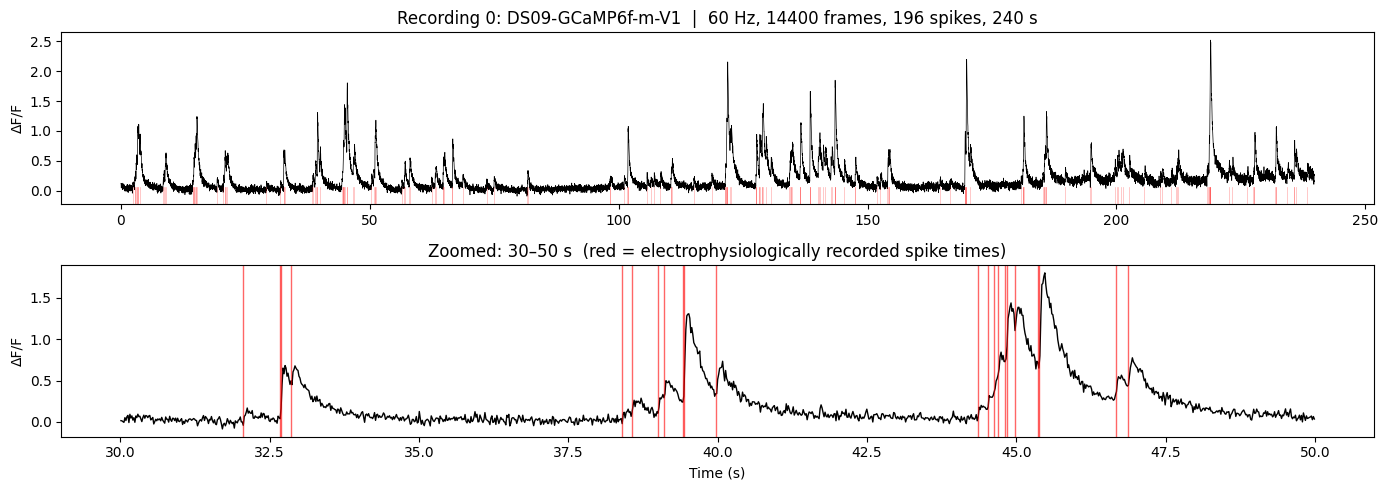

In [6]:
# Visualize an example training recording
idx = 0  # change this to browse different recordings
dff = data['train_dff'][idx]
t = data['train_t'][idx]
spikes = data['train_spikes'][idx]
fr = data['train_frame_rates'][idx]
ds_name = str(data['train_datasets'][idx])


fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Full trace
axes[0].plot(t, dff, 'k', linewidth=0.5)
for sp in spikes:
    axes[0].axvline(sp, color='red', alpha=0.3, linewidth=0.5, ymin=0, ymax=0.1)
axes[0].set_ylabel('ΔF/F')
axes[0].set_title(f'Recording {idx}: {ds_name}  |  {fr:.0f} Hz, {len(dff)} frames, '
                  f'{len(spikes)} spikes, {t[-1]:.0f} s')

# Zoomed window
t0, t1 = 30, 50
m = (t >= t0) & (t <= t1)
axes[1].plot(t[m], dff[m], 'k', linewidth=1)
for sp in spikes[(spikes >= t0) & (spikes <= t1)]:
    axes[1].axvline(sp, color='red', alpha=0.6, linewidth=1)
axes[1].set_ylabel('ΔF/F')
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'Zoomed: {t0}–{t1} s  (red = electrophysiologically recorded spike times)')

plt.tight_layout()
plt.show()

## Research question

<span style='background: purple'>Investigating and Mitigating Domain Shift in Deep Learning-Based Spike Inference Across Calcium Indicators
- How does the model architecture affect spike inference performance?
</span>



2. **Compare architectures.** Implement at least two different network architectures (e.g. the Cascade default, a deeper/shallower variant, one with skip connections or batch normalization). Which design choices matter most for spike inference performance?


## Checking baseline CASCADE performance on test data

##### 1. Loading ΔF/F traces

In [7]:
#@markdown ΔF/F traces must be saved as \*.npy-files (for Python) or \*.mat-files (for Matlab/Python) as a single large matrix named **`dF_traces`** (neurons x time). ΔF/F values of the input should be numeric, not in percent (e.g. 0.5 instead of 50%). For different input formats, the code in this box can be modified (it\'s not difficult).

def load_neurons_x_time(file_path):
    """Custom method to load data as 2d array with shape (neurons, nr_timepoints)"""

    if file_path.endswith('.mat'):
      traces = sio.loadmat(file_path)['dF_traces']
      # PLEASE NOTE: If you use mat73 to load large *.mat-file, be aware of potential numerical errors, see issue #67 (https://github.com/HelmchenLabSoftware/Cascade/issues/67)

    elif file_path.endswith('.npy'):
      traces = np.load(file_path, allow_pickle=True)
      # if saved data was a dictionary packed into a numpy array (MATLAB style): unpack
      if traces.shape == ():
        traces = traces.item()['dF_traces']

    else:
      raise Exception('This function only supports .mat or .npy files.')

    print('Traces standard deviation:', np.nanmean(np.nanstd(traces,axis=1)))
    if np.nanmedian(np.nanstd(traces,axis=1)) > 2:
      print('Fluctuations in dF/F are very large, probably dF/F is given in percent. Traces are divided by 100.')
      return traces/100
    else:
        return traces



##### 2. Select dataset, indicate frame rate, load traces and preprocess

In [8]:
def spikes_to_counts(spike_times, t):
    dt = t[1] - t[0]
    edges = np.append(t - dt/2, t[-1] + dt/2)
    counts, _ = np.histogram(spike_times, bins = edges)
    return counts.astype(float)

In [9]:
#Load data and resample to 30Hz
from scipy.signal import decimate
traces_list = data["test_dff"]
test_spikes = data["test_spikes"]
time = data["test_t"]
test_data = []
spike_counts = []


# downsample traces to 30 Hz

for i, t in enumerate(traces_list):
  test_data.append(decimate(t, 2))

np.save("test_dff.npy", test_data)

# adjust the time vectors to downsampes traces
for i in range(len(test_spikes)):
  spike_counts.append(spikes_to_counts(test_spikes[i], time[i]))

spike_counts = np.array(spike_counts)
resamp_spike_counts = (np.add.reduceat(spike_counts.T, np.arange(0, len(spike_counts.T), 2), axis=0)).T



In [10]:

example_file = "test_dff.npy"
frame_rate = 30 #@param {type:"number"}

try:

  traces = load_neurons_x_time( example_file )
  print('Number of neurons in dataset:', traces.shape[0])
  print('Number of timepoints in dataset:', traces.shape[1])

except Exception as e:

  print('\nSomething went wrong!\nEither the target file is missing, in this case please provide the correct location.\nOr your file is not yet completely uploaded, in this case wait until the upload is completed.\n')

  print('Error message: '+str(e))


Traces standard deviation: 0.565371
Number of neurons in dataset: 9
Number of timepoints in dataset: 5000


In [11]:
spike_counts.shape, resamp_spike_counts.shape, traces.shape

((9, 10000), (9, 5000), (9, 5000))

##### 3. Plot distribution of noise levels

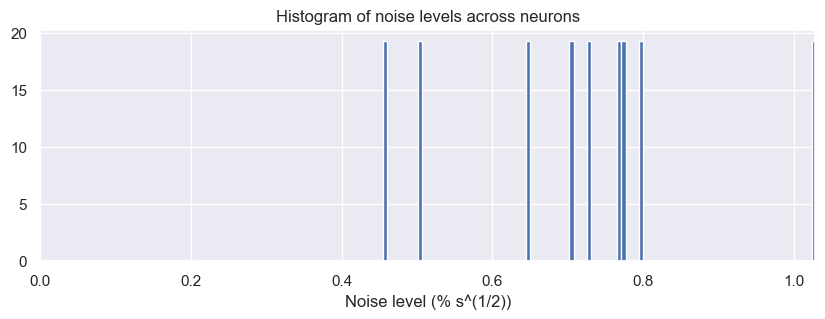

In [12]:
#@markdown For each neuron in the loaded dataset, the noise level will be computed and the distribution across neurons will be shown.
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = [10, 3]

noise_levels = plot_noise_level_distribution(traces,frame_rate)



##### 4. Plot calcium traces

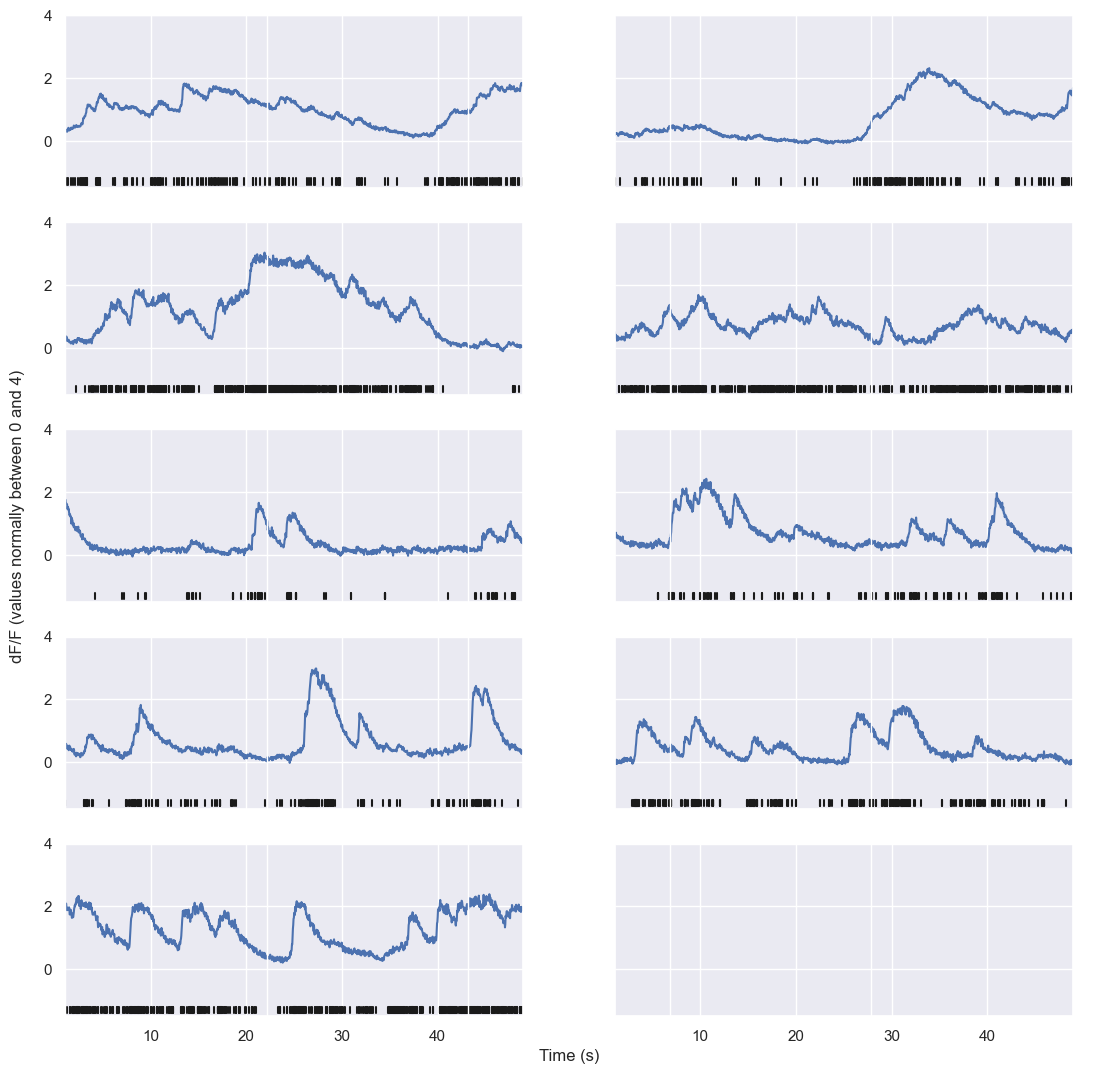

In [12]:
# Plotting traces helps to check whether the data have been loaded correctly.

plt.rcParams['figure.figsize'] = [13, 13]
discrete_spikes =  np.array([np.asarray(s) * frame_rate for s in test_spikes], dtype=object)

neuron_indices = np.arange(0, len(traces))  #np.random.randint(traces.shape[0], size=9)
time_axis = plot_dFF_traces(traces,neuron_indices,frame_rate, y_range=(-1.5, 4), discrete_spikes=discrete_spikes)




##### 5. Select Pretrained model from the CASCADE model zoo

In [22]:
#@markdown Get list of the names of available models.


cascade.download_model( 'update_models', model_folder=MODEL_FOLDER, verbose = 1)

MODEL_LIST = os.path.join(MODEL_FOLDER, "available_models_CascadeTorch.yaml")
yaml_file = open(MODEL_LIST)
X = yaml.load(yaml_file)
list_of_models = list(X.keys())
print('\n List of available models: \n')
for model in list_of_models:
  print(model)

You can now check the updated available_models_CascadeTorch.yaml file for valid model names.
File location: c:\Users\janaurmi\OneDrive\Docs\Germany_docs\Neural DS\CascadeTorch\Pretrained_models\available_models_CascadeTorch.yaml

 List of available models: 

GC8f_EXC_100Hz_smoothing10ms
GC8f_EXC_15Hz_smoothing100ms_high_noise
GC8f_EXC_15Hz_smoothing50ms_high_noise
GC8f_EXC_30Hz_smoothing25ms_high_noise
GC8f_EXC_30Hz_smoothing50ms_high_noise
GC8f_EXC_20Hz_smoothing40ms_high_noise
GC8f_EXC_7.5Hz_smoothing100ms_high_noise
GC8f_EXC_7.5Hz_smoothing200ms_high_noise
GC8m_EXC_15Hz_smoothing100ms_high_noise
GC8m_EXC_15Hz_smoothing50ms_high_noise
GC8m_EXC_30Hz_smoothing25ms_high_noise
GC8m_EXC_30Hz_smoothing50ms_high_noise
GC8m_EXC_7.5Hz_smoothing100ms_high_noise
GC8m_EXC_7.5Hz_smoothing200ms_high_noise
GC8s_EXC_15Hz_smoothing100ms_high_noise
GC8s_EXC_15Hz_smoothing50ms_high_noise
GC8s_EXC_20Hz_smoothing30ms_high_noise
GC8s_EXC_20Hz_smoothing60ms_high_noise
GC8s_EXC_30Hz_smoothing25ms_high_noise

In [23]:

# Select (from the list above) and download the model that fits to your dataset (frame rate, training data; see FAQ for more details) and assign to variable **`model_name`**.

model_name = "Global_EXC_30Hz_smoothing25ms" 
cascade.download_model( model_name,model_folder=MODEL_FOLDER,verbose = 1)

Pretrained model was saved in folder "c:\Users\janaurmi\OneDrive\Docs\Germany_docs\Neural DS\CascadeTorch\Pretrained_models\Global_EXC_30Hz_smoothing25ms"


##### 6. Predict and plot expected spikes from the traces

In [24]:
# If this takes too long, make sure that the GPU runtime is activated (*Menu > Runtime > Change Runtime Type*).

total_array_size = traces.itemsize*traces.size*64/1e9
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# If the expected array size is too large for the Colab Notebook, split up for processing
if total_array_size < 1:
  spike_prob = cascade.predict( model_name, traces, model_folder=MODEL_FOLDER, device=device, verbosity=1 )

# Will only be use for large input arrays (long recordings or many neurons)
else:

  print("Split analysis into chunks in order to fit into Colab memory.")

  # pre-allocate array for results
  spike_prob = np.zeros((traces.shape))
  # nb of neurons and nb of chuncks
  nb_neurons = traces.shape[0]
  nb_chunks = int(np.ceil(total_array_size/1))

  chunks = np.array_split(range(nb_neurons), nb_chunks)
  # infer spike rates independently for each chunk
  for part_array in range(nb_chunks):
    spike_prob[chunks[part_array],:] = cascade.predict( model_name, traces[chunks[part_array],:], device=device )



 
The selected model was trained on 18 datasets, with 5 ensembles for each noise level, at a sampling rate of 30Hz, with a resampled ground truth that was smoothed with a Gaussian kernel of a standard deviation of 25 milliseconds. 
 

Loaded model was trained at frame rate 30 Hz
Given argument traces contains 9 neurons and 5000 frames.
Noise levels (mean, std; in standard units): 0.71, 0.15

Predictions for noise level 2:
	... ensemble 0
	... ensemble 1
	... ensemble 2
	... ensemble 3
	... ensemble 4

Predictions for noise level 3:
	No neurons for this noise level

Predictions for noise level 4:
	No neurons for this noise level

Predictions for noise level 5:
	No neurons for this noise level

Predictions for noise level 6:
	No neurons for this noise level

Predictions for noise level 7:
	No neurons for this noise level

Predictions for noise level 8:
	No neurons for this noise level

Predictions for noise level 9:
	No neurons for this noise level
Spike rate inference done.


In [25]:
global_spike_prob = spike_prob

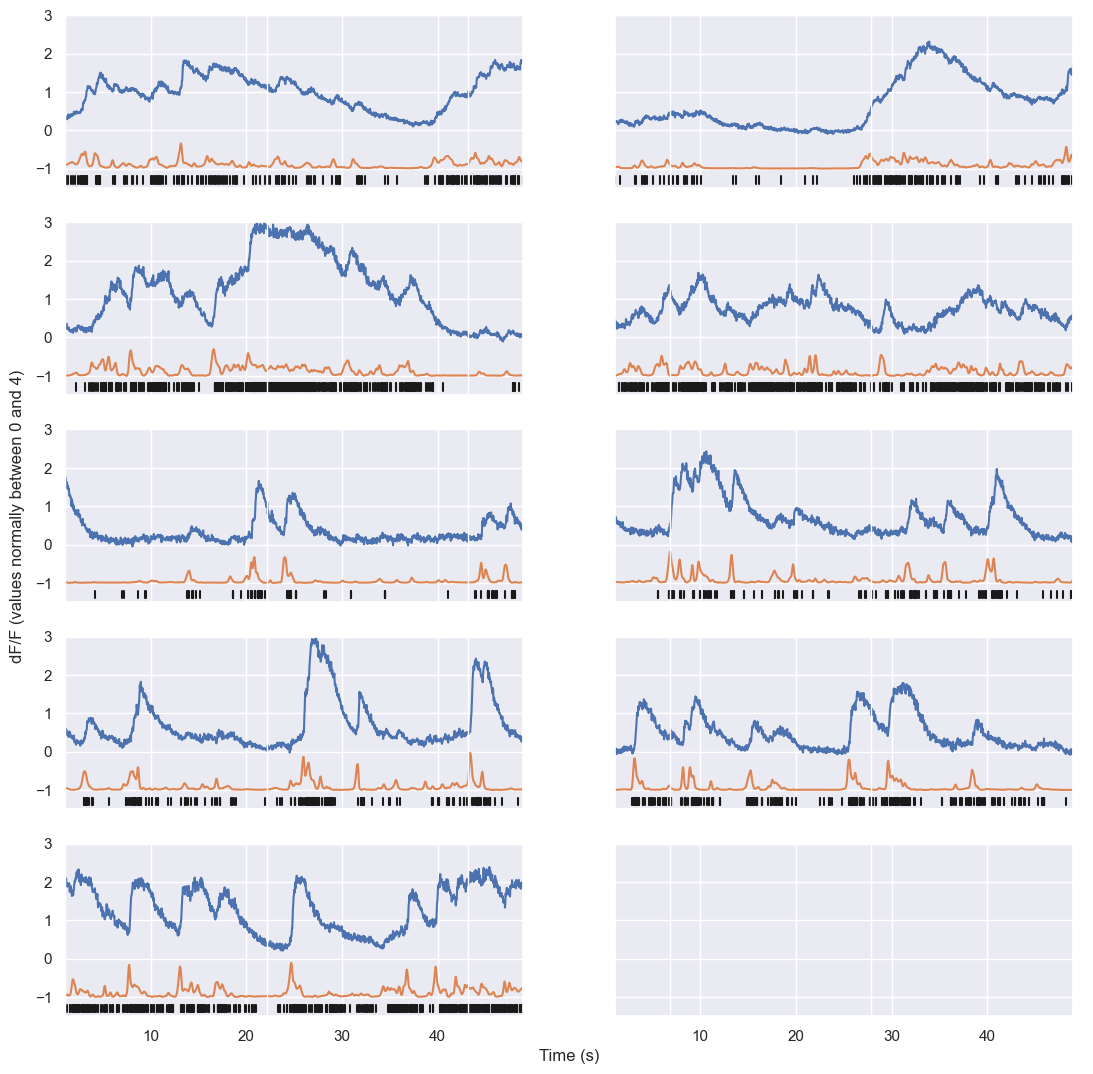

In [111]:
# plot expected spike probabilites as predicted 
#@markdown Plot first seconda of the test neurons. The dF/F traces are shown in blue, the inferred spike probability is plotted in orange (shifted downwards by 1 for better visibility).

neuron_indices = np.arange(0, len(traces)) #np.random.randint(traces.shape[0], size=nb_neurons)
time_axis = plot_dFF_traces(traces,neuron_indices,frame_rate, spike_prob,y_range=(-1.5, 3), discrete_spikes= discrete_spikes)

<Figure size 1000x500 with 0 Axes>

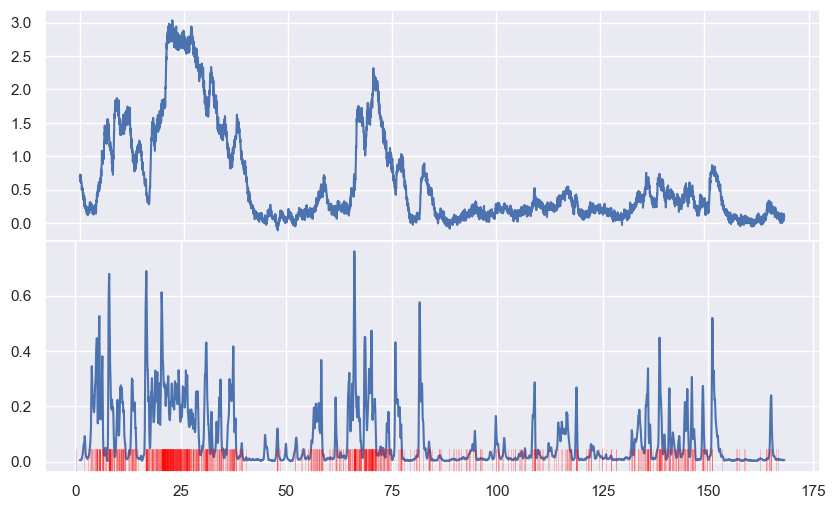

In [148]:
# plots for downsampled spike trace, predicted spikes and ground truth spikes
plt.figure(figsize=(10,5))
fig, axs = plt.subplots(
    2, 1, figsize=(10, 6), height_ratios=[ 1, 1], gridspec_kw=dict(hspace=0)
)

idx=2
t = time[idx][::2]
axs[0].plot(t, traces[idx])
axs[1].plot(t, global_spike_prob[idx])
# axs[1].plot(resamp_spike_counts)
for sp in test_spikes[idx]:
    axs[1].axvline(sp, color='red', alpha=0.3, linewidth=0.5, ymin=0, ymax=0.1)

#### 9. Testing the indicator specific model

In [38]:

# Select (from the list above) and download the model that fits to your dataset (frame rate, training data; see FAQ for more details) and assign to variable **`model_name`**.

model_name = "GC8s_EXC_30Hz_smoothing50ms_high_noise" 

cascade.download_model( model_name,model_folder=MODEL_FOLDER,verbose = 1)

total_array_size = traces.itemsize*traces.size*64/1e9
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if total_array_size < 1:
  spike_prob = cascade.predict( model_name, traces, model_folder=MODEL_FOLDER, device=device, verbosity=1 )

# Will only be use for large input arrays (long recordings or many neurons)
else:

  print("Split analysis into chunks in order to fit into Colab memory.")

  # pre-allocate array for results
  spike_prob = np.zeros((traces.shape))
  # nb of neurons and nb of chuncks
  nb_neurons = traces.shape[0]
  nb_chunks = int(np.ceil(total_array_size/1))

  chunks = np.array_split(range(nb_neurons), nb_chunks)
  # infer spike rates independently for each chunk
  for part_array in range(nb_chunks):
    spike_prob[chunks[part_array],:] = cascade.predict( model_name, traces[chunks[part_array],:], device=device )


Pretrained model was saved in folder "c:\Users\janaurmi\OneDrive\Docs\Germany_docs\Neural DS\CascadeTorch\Pretrained_models\GC8s_EXC_30Hz_smoothing50ms_high_noise"

 
The selected model was trained on 1 datasets, with 5 ensembles for each noise level, at a sampling rate of 30.0Hz, with a resampled ground truth that was smoothed with a Gaussian kernel of a standard deviation of 50 milliseconds. 
 

Loaded model was trained at frame rate 30.0 Hz
Given argument traces contains 9 neurons and 5000 frames.
Noise levels (mean, std; in standard units): 0.71, 0.15

Predictions for noise level 2:
	... ensemble 0
	... ensemble 1
	... ensemble 2
	... ensemble 3
	... ensemble 4

Predictions for noise level 3:
	No neurons for this noise level

Predictions for noise level 4:
	No neurons for this noise level

Predictions for noise level 5:
	No neurons for this noise level

Predictions for noise level 6:
	No neurons for this noise level

Predictions for noise level 8:
	No neurons for this noise level



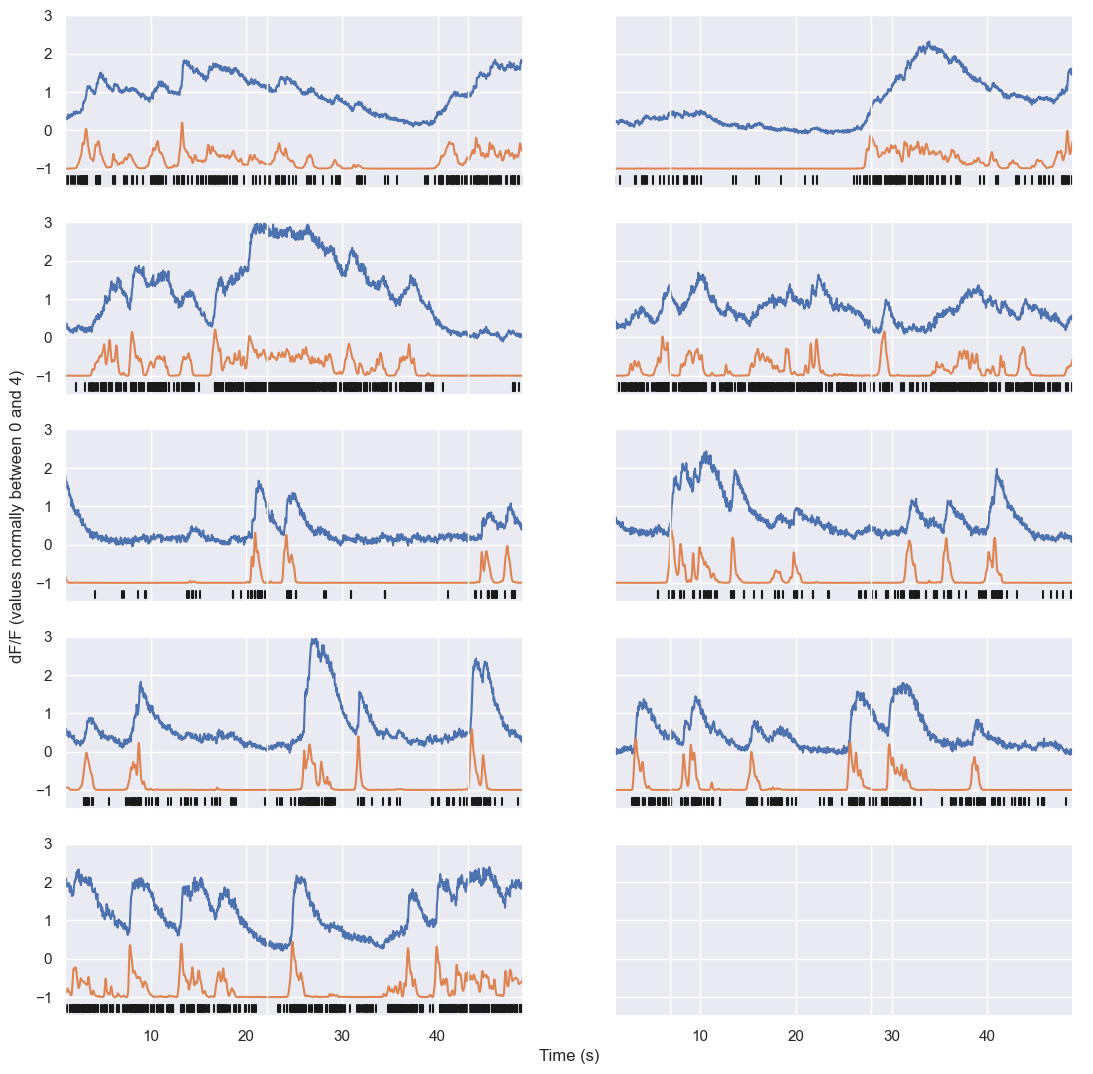

In [39]:
# plot expected spike probabilites as predicted 
#@markdown Plot first seconda of the test neurons. The dF/F traces are shown in blue, the inferred spike probability is plotted in orange (shifted downwards by 1 for better visibility).

neuron_indices = np.arange(0, len(traces)) #np.random.randint(traces.shape[0], size=nb_neurons)
time_axis = plot_dFF_traces(traces,neuron_indices,frame_rate, spike_prob,y_range=(-1.5, 3), discrete_spikes= discrete_spikes)

In [40]:
gcamp_spike_prob = spike_prob

<Figure size 1000x500 with 0 Axes>

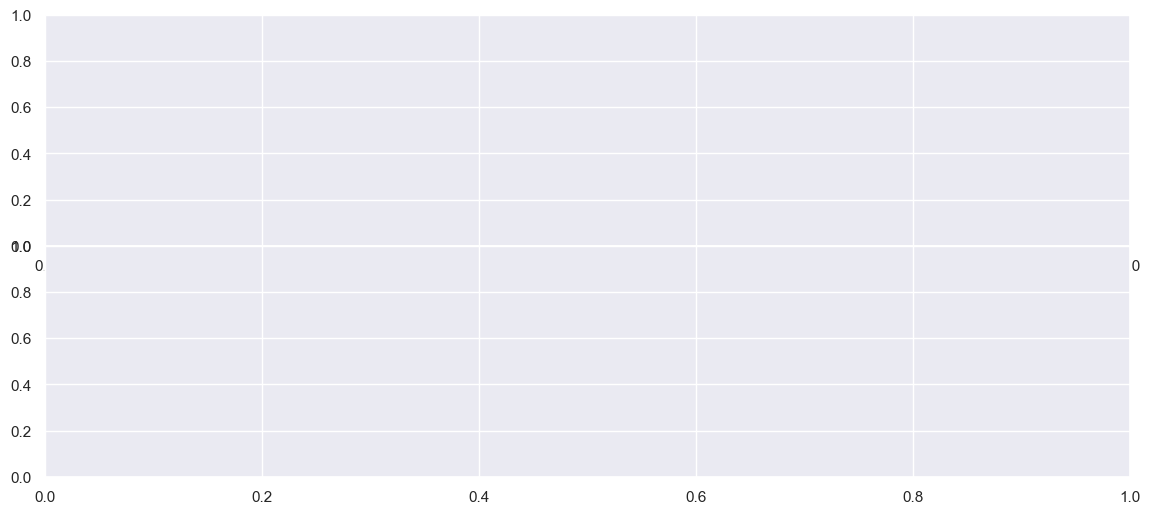

In [87]:
# plots for downsampled spike trace, predicted spikes and ground truth spikes
plt.figure(figsize=(10,5))
fig, axes = plt.subplots(
    2, 1, figsize=(14, 6), height_ratios=[ 1, 1], gridspec_kw=dict(hspace=0)
)

idx=2
t = time[idx][::2]
dff = traces[idx]
spikes = test_spikes[idx]
# axs[0].plot(t, traces[idx])
# axs[1].plot(t, gcamp_spike_prob[idx])
# # axs[1].plot(resamp_spike_counts)
# for sp in test_spikes[idx]:
#     axs[1].axvline(sp, color='red', alpha=0.3, linewidth=0.5, ymin=0, ymax=0.1)


# Zoomed window


#### 10. Measure correlation for each neuron measured from the model

In [149]:
import pandas as pd

def neuron_correlation(pred, counts):
    """Pearson r between one neuron's predicted rate and its resampled spike counts.
    Handles CASCADE's NaN padding and any small length mismatch from resampling."""
    n = min(len(pred), len(counts))
    a, b = np.asarray(pred[:n], float), np.asarray(counts[:n], float)
    ok = np.isfinite(a) & np.isfinite(b)          # drop NaN-padded edges
    if ok.sum() < 2 or a[ok].std() == 0 or b[ok].std() == 0:
        return np.nan
    return np.corrcoef(a[ok], b[ok])[0, 1]

def indicator_of(field):
    """Read the calcium indicator (GCaMP6f / GCaMP6s) from the dataset name."""
    s = str(np.atleast_1d(field).ravel()[0])
    return 'GCaMP6f' if '6f' in s else 'GCaMP6s' if '6s' in s else s

# one entry per (model, neuron)
models = {'Global': global_spike_prob, 'GCaMP8s': gcamp_spike_prob}

rows = []
for algo, probs in models.items():
    for i in range(len(probs)):
        rows.append({
            'algorithm':   algo,
            'correlation': neuron_correlation(probs[i], resamp_spike_counts[i]),
            'indicator':   indicator_of(data['test_datasets'][i]),
        })

df_results = pd.DataFrame(rows)
print(df_results.head())
print(f"\nShape: {df_results.shape}")
print(df_results.groupby('algorithm')['correlation'].mean())

  algorithm  correlation indicator
0    Global     0.363468   GCaMP6s
1    Global     0.357837   GCaMP6s
2    Global     0.499266   GCaMP6s
3    Global     0.478921   GCaMP6s
4    Global     0.567149   GCaMP6s

Shape: (18, 3)
algorithm
GCaMP8s    0.339550
Global     0.447737
Name: correlation, dtype: float64


Text(0.5, 1.0, 'Zoomed: 30–50 s  (red = electrophysiologically recorded spike times)')

<Figure size 1000x500 with 0 Axes>

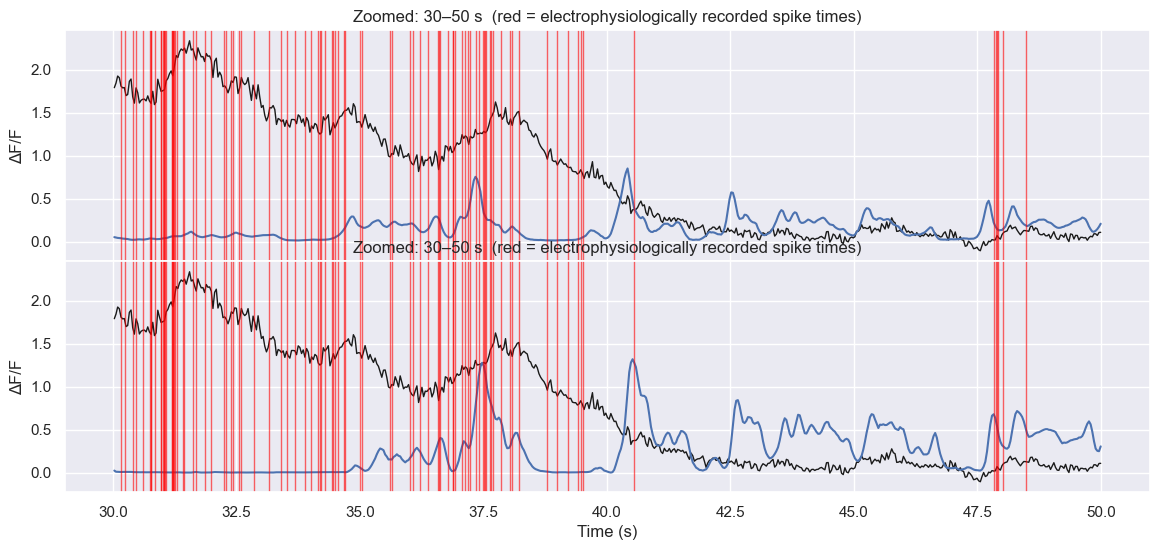

In [153]:
# zoomed plot for comparison
# main takeaway = the GCamp8s model cannot properly capture the indicator performance since it's faster than the GCamp6s indicator and misses some
# spikes that the Global model can pick up

plt.figure(figsize=(10,5))
fig, axes = plt.subplots(
    2, 1, figsize=(14, 6), height_ratios=[ 1, 1], gridspec_kw=dict(hspace=0)
)

idx=8
t0, t1 = 30, 50

m = (t >= t0) & (t <= t1)
axes[0].plot(t[m], dff[m], 'k', linewidth=1)
axes[0].plot(t[m], global_spike_prob[idx][m])
for sp in spikes[(spikes >= t0) & (spikes <= t1)]:
    axes[0].axvline(sp, color='red', alpha=0.6, linewidth=1)
axes[0].set_ylabel('ΔF/F')
axes[0].set_xlabel('Time (s)')
axes[0].set_title(f'Zoomed: {t0}–{t1} s  (red = electrophysiologically recorded spike times)')



m = (t >= t0) & (t <= t1)
axes[1].plot(t[m], dff[m], 'k', linewidth=1)
axes[1].plot(t[m], gcamp_spike_prob[idx][m])
for sp in spikes[(spikes >= t0) & (spikes <= t1)]:
    axes[1].axvline(sp, color='red', alpha=0.6, linewidth=1)
axes[1].set_ylabel('ΔF/F')
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'Zoomed: {t0}–{t1} s  (red = electrophysiologically recorded spike times)')


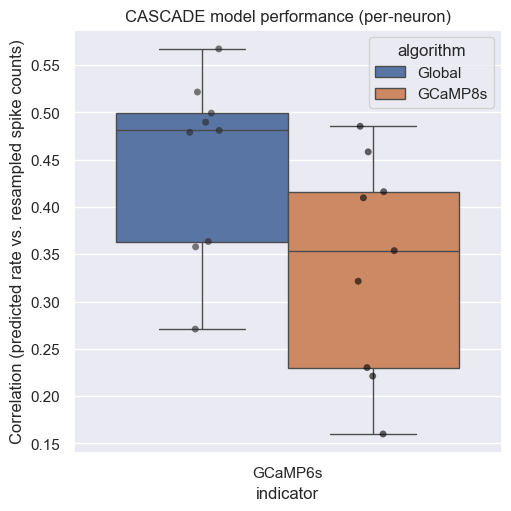

In [151]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(5,5), layout="constrained")
sns.boxplot(data=df_results, x='indicator', y='correlation', hue='algorithm', ax=ax)
sns.stripplot(data=df_results, x='indicator', y='correlation', hue='algorithm',
              dodge=True, alpha=0.6, palette='dark:black', ax=ax, legend=False)
ax.set_title('CASCADE model performance (per-neuron)')
ax.set_ylabel('Correlation (predicted rate vs. resampled spike counts)')
plt.show()

#### Abalations to determine the significant aspects of the model architecture and noise matching method

##### 1. Noise matching algorithm

In [58]:
# we use the Donoho–Johnstone wavelet MAD noise estimation (Symlet 4) wavelet function to check if it works better than CASCADE's 
# per neuron noise estimation
    
def calculate_noise_levels_sym4(neurons_x_time, frame_rate, wavelet='sym4'):
    """
    Drop-in replacement for cascade2p.utils.calculate_noise_levels.

    Instead of the median absolute frame-to-frame difference, it estimates the
    noise from the level-1 detail coefficients of a sym4 (Symlet-4) wavelet
    transform — the Donoho–Johnstone robust (MAD) noise estimator. This isolates
    the high-frequency (noise) band while rejecting real calcium transients that
    can inflate the difference-based estimate.

    Output is on the SAME scale as CASCADE's original estimator (percent,
    normalised by sqrt(frame_rate)), so the noise-matched model selection in
    cascade.predict() still works.

    Parameters
    ----------
    neurons_x_time : 1d or 2d array  (neurons x timepoints)
    frame_rate     : float, Hz
    wavelet        : str, PyWavelets wavelet name (default 'sym4')

    Returns
    -------
    noise_levels : 1d array (one value per neuron)
    """
    traces = np.atleast_2d(np.asarray(neurons_x_time, dtype=float))
    noise = np.full(traces.shape[0], np.nan)

    for i, x in enumerate(traces):
        x = x[np.isfinite(x)]                     # ignore NaN padding
        if x.size < 8:                            # need enough points for the DWT
            continue
        # level-1 sym4 detail coefficients ≈ the high-frequency / noise band
        _, cD1 = pywt.dwt(x, wavelet, mode='periodization')
        # robust scale: median(|cD1|) = 0.6745 * sigma for white noise
        median_detail = np.median(np.abs(cD1))
        # rescale to CASCADE's median(|diff|) convention:
        # for white noise, median(|diff|) == sqrt(2) * median(|cD1|)
        noise[i] = np.sqrt(2.0) * median_detail

    return noise / np.sqrt(frame_rate) * 100.0


In [64]:

# check output on global model
model_name = "Global_EXC_30Hz_smoothing50ms_high_noise" #"Global_EXC_30Hz_smoothing100ms" #"Global_EXC_30Hz_smoothing50ms_high_noise" 

cascade.download_model( model_name,model_folder=MODEL_FOLDER,verbose = 1)

total_array_size = traces.itemsize*traces.size*64/1e9
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if total_array_size < 1:
  spike_prob = cascade.predict( model_name, traces, model_folder=MODEL_FOLDER, device=device, verbosity=1 )

# Will only be use for large input arrays (long recordings or many neurons)
else:

  print("Split analysis into chunks in order to fit into Colab memory.")

  # pre-allocate array for results
  spike_prob = np.zeros((traces.shape))
  # nb of neurons and nb of chuncks
  nb_neurons = traces.shape[0]
  nb_chunks = int(np.ceil(total_array_size/1))

  chunks = np.array_split(range(nb_neurons), nb_chunks)
  # infer spike rates independently for each chunk
  for part_array in range(nb_chunks):
    spike_prob[chunks[part_array],:] = cascade.predict( model_name, traces[chunks[part_array],:], trace_noise_levels=calculate_noise_levels_sym4,device=device )


Pretrained model was saved in folder "c:\Users\janaurmi\OneDrive\Docs\Germany_docs\Neural DS\CascadeTorch\Pretrained_models\Global_EXC_30Hz_smoothing50ms_high_noise"

 
The selected model was trained on 18 datasets, with 5 ensembles for each noise level, at a sampling rate of 30Hz, with a resampled ground truth that was smoothed with a Gaussian kernel of a standard deviation of 50 milliseconds. 
 

Loaded model was trained at frame rate 30 Hz
Given argument traces contains 9 neurons and 5000 frames.
Noise levels (mean, std; in standard units): 0.71, 0.15

Predictions for noise level 2:
	... ensemble 0
	... ensemble 1
	... ensemble 2
	... ensemble 3
	... ensemble 4

Predictions for noise level 3:
	No neurons for this noise level

Predictions for noise level 4:
	No neurons for this noise level

Predictions for noise level 5:
	No neurons for this noise level

Predictions for noise level 6:
	No neurons for this noise level

Predictions for noise level 7:
	No neurons for this noise level

P

In [65]:
noise_global_spike_prob = spike_prob

In [66]:
# plot and check correlation
import pandas as pd

def neuron_correlation(pred, counts):
    """Pearson r between one neuron's predicted rate and its resampled spike counts.
    Handles CASCADE's NaN padding and any small length mismatch from resampling."""
    n = min(len(pred), len(counts))
    a, b = np.asarray(pred[:n], float), np.asarray(counts[:n], float)
    ok = np.isfinite(a) & np.isfinite(b)          # drop NaN-padded edges
    if ok.sum() < 2 or a[ok].std() == 0 or b[ok].std() == 0:
        return np.nan
    return np.corrcoef(a[ok], b[ok])[0, 1]

def indicator_of(field):
    """Read the calcium indicator (GCaMP6f / GCaMP6s) from the dataset name."""
    s = str(np.atleast_1d(field).ravel()[0])
    return 'GCaMP6f' if '6f' in s else 'GCaMP6s' if '6s' in s else s

# one entry per (model, neuron)
models = {'CASCADE': global_spike_prob, 'Wavelets': noise_global_spike_prob}

rows = []
for algo, probs in models.items():
    for i in range(len(probs)):
        rows.append({
            'algorithm':   algo,
            'correlation': neuron_correlation(probs[i], resamp_spike_counts[i]),
            'indicator':   indicator_of(data['test_datasets'][i]),
        })

df_results = pd.DataFrame(rows)
print(df_results.head())
print(f"\nShape: {df_results.shape}")
print(df_results.groupby('algorithm')['correlation'].mean())

  algorithm  correlation indicator
0   CASCADE     0.360305   GCaMP6s
1   CASCADE     0.351642   GCaMP6s
2   CASCADE     0.490172   GCaMP6s
3   CASCADE     0.471589   GCaMP6s
4   CASCADE     0.556945   GCaMP6s

Shape: (18, 3)
algorithm
CASCADE     0.439795
Wavelets    0.439795
Name: correlation, dtype: float64


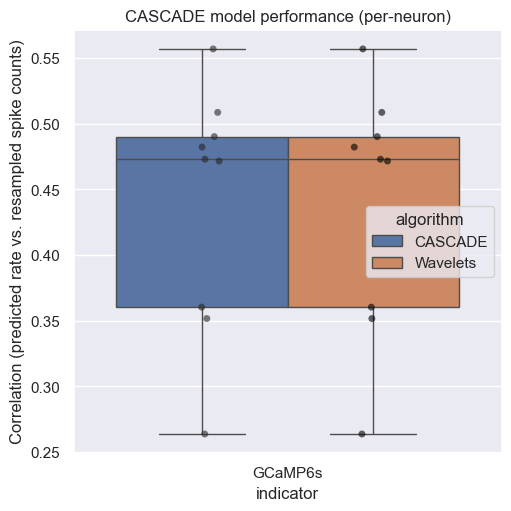

In [67]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(5,5), layout="constrained")
sns.boxplot(data=df_results, x='indicator', y='correlation', hue='algorithm', ax=ax)
sns.stripplot(data=df_results, x='indicator', y='correlation', hue='algorithm',
              dodge=True, alpha=0.6, palette='dark:black', ax=ax, legend=False)
ax.set_title('CASCADE model performance (per-neuron)')
ax.set_ylabel('Correlation (predicted rate vs. resampled spike counts)')
plt.show()

but why?

##### 11. Abalations over the model architecture

##### 1. Select and retrain a baseline for training with limited training infrastructure

In [ ]:
# choosing the 3 models: Global 50ms smoothing, Global 100 ms smoothing, GCamp8s model

def train_architecture(cfg, model_folder, mode = "CASCADE", type=None):
    """
    script to train a network based on:

    - a range of noise levels
    - a given frame rate
    - a selection of ground truth data sets

    The model configuration is defined based on a couple of parameters (sampling rate,
    training data sets, noise levels, ground truth smoothing). A folder is generated
    on the hard disk with the name 'model_name'.

    Finally, the model is trained, "cascade.train_model( model_name )" and the trained
    models are saved to disk.

    """

    """

    Generate folder on hard disk for model

    """

    cascade.create_model_folder(cfg, model_folder)

    print('\nTo load this model, use the model name "{}"'.format(cfg["model_name"]))


    """

    Train model for all datasets and noise levels

    """

    model_name = cfg["model_name"]

    print(model)
    if mode == "CASCADE": cascade.train_model(model_name, model_folder, ground_truth_folder=GT_FOLDER)
    else: helper.train_model(model_name, model, model_folder, ground_truth_folder=GT_FOLDER, type="shallow")

    print("Model trained")


In [161]:
"""

Configure model and its parameters

"""

cfg = dict(
    model_name="Global_30Hz_25ms_baseline",  # Model name (and name of the save folder)
    sampling_rate=30,  # Sampling rate in Hz (round to next integer)
    training_datasets=[
        "DS12-GCaMP6s-m-V1-neuropil-corrected",
        "DS13-GCaMP6s-m-V1-neuropil-corrected",
        "DS14-GCaMP6s-m-V1",
    ],
    noise_levels=[
        noise for noise in range(2, 3)
    ],  
    smoothing=0.025,  # std of Gaussian smoothing in time (sec)
    causal_kernel=0,  # causal ground truth smoothing kernel
    nr_of_epochs= 10,   
    ensemble_size = 3,
)

train_architecture(cfg, model_folder="./")


To load this model, use the model name "Global_30Hz_25ms_baseline"
Used configuration for model fitting (file c:\Users\janaurmi\OneDrive\Docs\Germany_docs\Neural DS\Indicator_performance\Global_30Hz_25ms_baseline\config.yaml):

model_name:	Global_30Hz_25ms_baseline
sampling_rate:	30
training_datasets:	['DS12-GCaMP6s-m-V1-neuropil-corrected', 'DS13-GCaMP6s-m-V1-neuropil-corrected', 'DS14-GCaMP6s-m-V1']
placeholder_1:	0
noise_levels:	[2]
placeholder_2:	0
smoothing:	0.025
causal_kernel:	0
windowsize:	64
before_frac:	0.5
filter_sizes:	[31, 19, 5]
filter_numbers:	[30, 40, 50]
dense_expansion:	10
loss_function:	mean_squared_error
optimizer:	Adagrad
nr_of_epochs:	10
ensemble_size:	3
batch_size:	1024
training_finished:	Running
verbose:	1


Models will be saved into this folder: c:\Users\janaurmi\OneDrive\Docs\Germany_docs\Neural DS\Indicator_performance\Global_30Hz_25ms_baseline
Fitting a total of 3 models:
../CascadeTorch\Ground_truth\DS12-GCaMP6s-m-V1-neuropil-corrected

Fitting model 1 wit

In [14]:
# evaluate trained model performance


# Select (from the list above) and download the model that fits to your dataset (frame rate, training data; see FAQ for more details) and assign to variable **`model_name`**.

model_name = "Global_30Hz_25ms_baseline" 

total_array_size = traces.itemsize*traces.size*64/1e9
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if total_array_size < 1:
  spike_prob = cascade.predict( model_name, traces, model_folder="./", device=device, verbosity=1 )

# Will only be use for large input arrays (long recordings or many neurons)
else:

  print("Split analysis into chunks in order to fit into Colab memory.")

  # pre-allocate array for results
  spike_prob = np.zeros((traces.shape))
  # nb of neurons and nb of chuncks
  nb_neurons = traces.shape[0]
  nb_chunks = int(np.ceil(total_array_size/1))

  chunks = np.array_split(range(nb_neurons), nb_chunks)
  # infer spike rates independently for each chunk
  for part_array in range(nb_chunks):
    spike_prob[chunks[part_array],:] = cascade.predict( model_name, traces[chunks[part_array],:], device=device )



 
The selected model was trained on 3 datasets, with 3 ensembles for each noise level, at a sampling rate of 30Hz, with a resampled ground truth that was smoothed with a Gaussian kernel of a standard deviation of 25 milliseconds. 
 

Loaded model was trained at frame rate 30 Hz
Given argument traces contains 9 neurons and 5000 frames.
Noise levels (mean, std; in standard units): 0.71, 0.15

Predictions for noise level 2:
	... ensemble 0
	... ensemble 1
	... ensemble 2
Spike rate inference done.


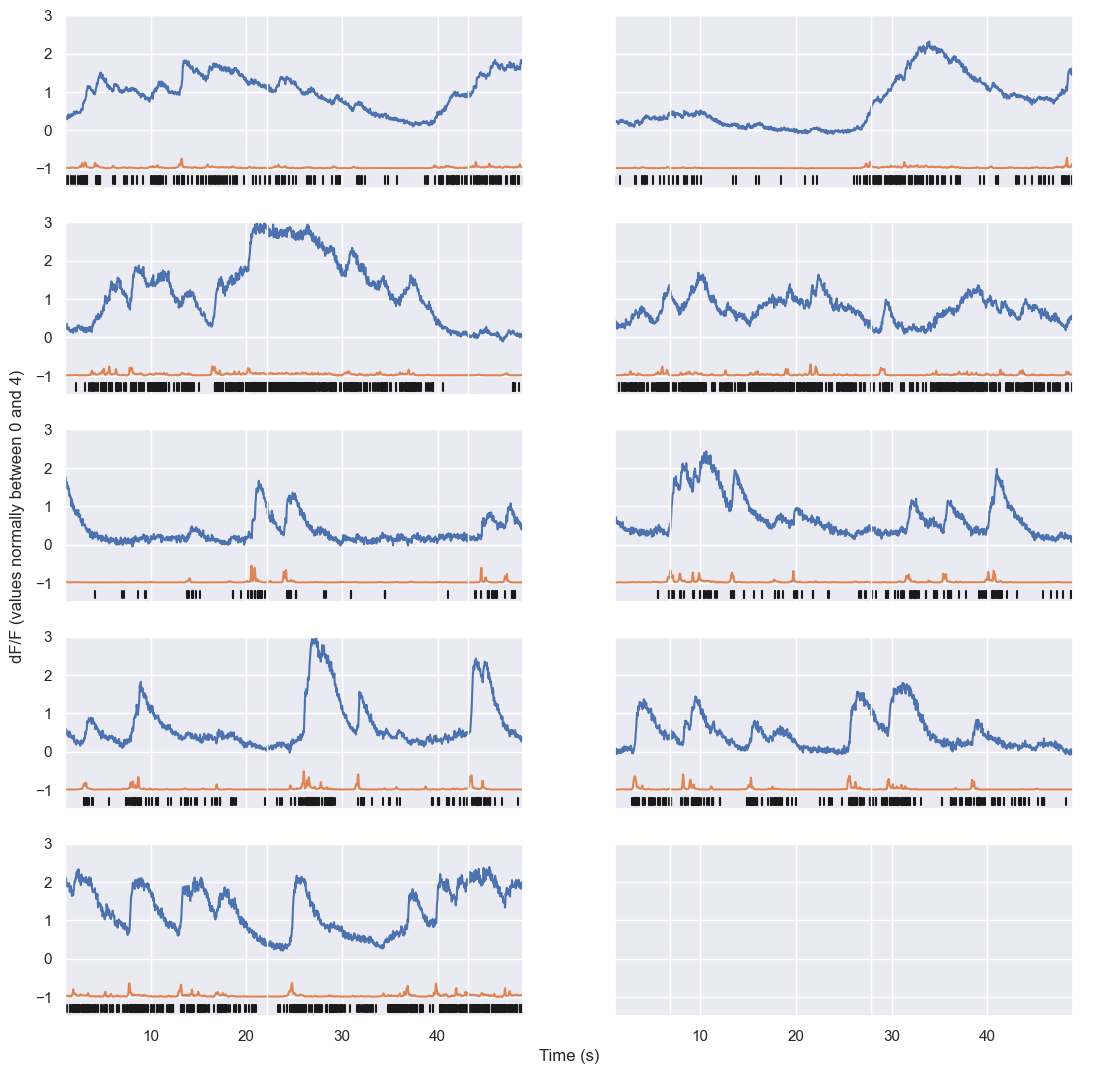

In [17]:
baseline = spike_prob

# plot expected spike probabilites as predicted 
#@markdown Plot first seconda of the test neurons. The dF/F traces are shown in blue, the inferred spike probability is plotted in orange (shifted downwards by 1 for better visibility).

neuron_indices = np.arange(0, len(traces)) #np.random.randint(traces.shape[0], size=nb_neurons)
time_axis = plot_dFF_traces(traces,neuron_indices,frame_rate, spike_prob,y_range=(-1.5, 3), discrete_spikes= discrete_spikes)

<Figure size 1000x500 with 0 Axes>

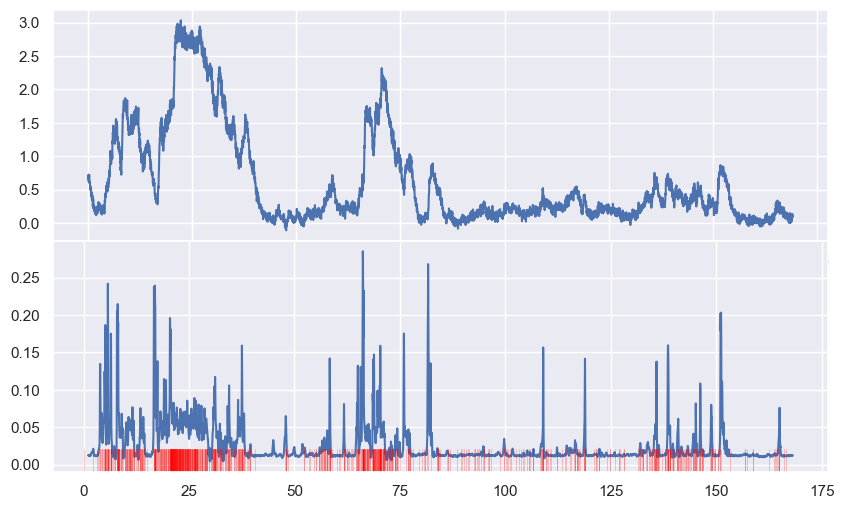

In [18]:
# plots for downsampled spike trace, predicted spikes and ground truth spikes
plt.figure(figsize=(10,5))
fig, axs = plt.subplots(
    2, 1, figsize=(10, 6), height_ratios=[ 1, 1], gridspec_kw=dict(hspace=0)
)

idx=2
t = time[idx][::2]
axs[0].plot(t, traces[idx])
axs[1].plot(t, baseline[idx])
# axs[1].plot(resamp_spike_counts)
for sp in test_spikes[idx]:
    axs[1].axvline(sp, color='red', alpha=0.3, linewidth=0.5, ymin=0, ymax=0.1)

In [26]:
# plot and check correlation
import pandas as pd

def neuron_correlation(pred, counts):
    """Pearson r between one neuron's predicted rate and its resampled spike counts.
    Handles CASCADE's NaN padding and any small length mismatch from resampling."""
    n = min(len(pred), len(counts))
    a, b = np.asarray(pred[:n], float), np.asarray(counts[:n], float)
    ok = np.isfinite(a) & np.isfinite(b)          # drop NaN-padded edges
    if ok.sum() < 2 or a[ok].std() == 0 or b[ok].std() == 0:
        return np.nan
    return np.corrcoef(a[ok], b[ok])[0, 1]

def indicator_of(field):
    """Read the calcium indicator (GCaMP6f / GCaMP6s) from the dataset name."""
    s = str(np.atleast_1d(field).ravel()[0])
    return 'GCaMP6f' if '6f' in s else 'GCaMP6s' if '6s' in s else s

# one entry per (model, neuron)
models = {'CASCADE': global_spike_prob, 'Retrained Baseline': baseline}

rows = []
for algo, probs in models.items():
    for i in range(len(probs)):
        rows.append({
            'algorithm':   algo,
            'correlation': neuron_correlation(probs[i], resamp_spike_counts[i]),
            'indicator':   indicator_of(data['test_datasets'][i]),
        })

df_results = pd.DataFrame(rows)
print(df_results.head())
print(f"\nShape: {df_results.shape}")
print(df_results.groupby('algorithm')['correlation'].mean())

  algorithm  correlation indicator
0   CASCADE     0.363457   GCaMP6s
1   CASCADE     0.357841   GCaMP6s
2   CASCADE     0.499259   GCaMP6s
3   CASCADE     0.478918   GCaMP6s
4   CASCADE     0.567145   GCaMP6s

Shape: (18, 3)
algorithm
CASCADE               0.447733
Retrained Baseline    0.423697
Name: correlation, dtype: float64


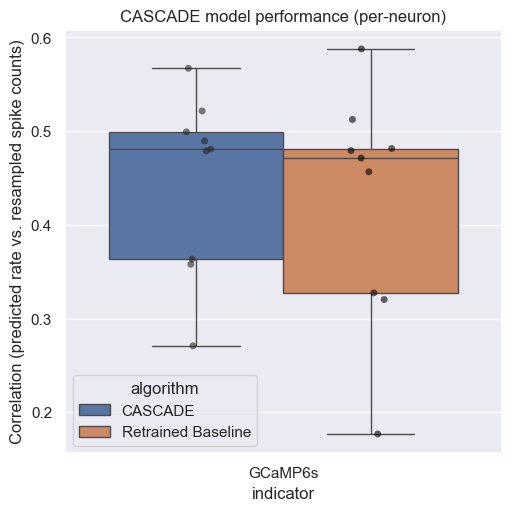

In [27]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(5,5), layout="constrained")
sns.boxplot(data=df_results, x='indicator', y='correlation', hue='algorithm', ax=ax)
sns.stripplot(data=df_results, x='indicator', y='correlation', hue='algorithm',
              dodge=True, alpha=0.6, palette='dark:black', ax=ax, legend=False)
ax.set_title('CASCADE model performance (per-neuron)')
ax.set_ylabel('Correlation (predicted rate vs. resampled spike counts)')
plt.show()

##### 2. Train with self defined architecture

In [15]:
import helper

"""

Configure model and its parameters

"""

cfg = dict(
    model_name="Global_30Hz_25ms_shallow_model",  # Model name (and name of the save folder)
    sampling_rate=30,  # Sampling rate in Hz (round to next integer)
    training_datasets=[
        "DS12-GCaMP6s-m-V1-neuropil-corrected",
        "DS13-GCaMP6s-m-V1-neuropil-corrected",
        "DS14-GCaMP6s-m-V1",
    ],
    noise_levels=[
        noise for noise in range(2, 3)
    ],  
    smoothing=0.025,  # std of Gaussian smoothing in time (sec)
    causal_kernel=0,  # causal ground truth smoothing kernel
    nr_of_epochs= 10,   
    ensemble_size = 3,
    filter_numbers = [20, 30, 40, 50],
    filter_sizes = [31, 19, 5]
)



train_architecture(cfg, model_folder="./", mode="Manual", type="shallow")


To load this model, use the model name "Global_30Hz_25ms_shallow_model"
CascadeModel(
  (conv1): Conv1d(1, 20, kernel_size=(31,), stride=(1,))
  (relu1): ReLU()
  (conv2): Conv1d(20, 30, kernel_size=(25,), stride=(1,))
  (relu2): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dense1): Linear(in_features=30, out_features=10, bias=True)
  (relu3): ReLU()
  (dense2): Linear(in_features=50, out_features=1, bias=True)
)
Manual mode training
Used configuration for model fitting (file c:\Users\janaurmi\OneDrive\Docs\Germany_docs\Neural DS\Indicator_performance\Global_30Hz_25ms_shallow_model\config.yaml):

model_name:	Global_30Hz_25ms_shallow_model
sampling_rate:	30
training_datasets:	['DS12-GCaMP6s-m-V1-neuropil-corrected', 'DS13-GCaMP6s-m-V1-neuropil-corrected', 'DS14-GCaMP6s-m-V1']
placeholder_1:	0
noise_levels:	[2]
placeholder_2:	0
smoothing:	0.025
causal_kernel:	0
windowsize:	64
before_frac:	0.5
filter_sizes:	[31, 25, 19, 5]
filter_numbers

RepresenterError: cannot represent an object: np.int64(10)

In [ ]:
# ============================================================================
# Evaluate the trained SHALLOW model: run CASCADE prediction on the test traces.
#
# cascade.predict() always builds the network with the 3-conv utils.define_model.
# That is INCOMPATIBLE with our 2-conv shallow model (its size formula yields a
# negative dense-layer size -> "negative dimension" crash). Fix: temporarily
# swap in helper.shallower_model while predicting the shallow model only.
# ============================================================================
from contextlib import contextmanager
import cascade2p.utils as _u

@contextmanager
def use_builder(builder):
    """Temporarily make cascade.predict build models with `builder`."""
    orig = _u.define_model
    _u.define_model = builder
    try:
        yield
    finally:
        _u.define_model = orig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Shallow model (2-conv) -> build with helper.shallower_model ---
with use_builder(helper.shallower_model):
    spike_prob_shallow = cascade.predict(
        "Global_30Hz_25ms_shallow_model", traces,
        model_folder="./", device=device, verbosity=1)

spike_prob = spike_prob_shallow          # keep the name later cells expect
np.save("spike_prob_shallow.npy", spike_prob_shallow)

print("\nShallow prediction done:",
      "shape", spike_prob_shallow.shape,
      "| finite", round(float(np.mean(np.isfinite(spike_prob_shallow))), 3),
      "| total inferred spikes", round(float(np.nansum(spike_prob_shallow)), 1))

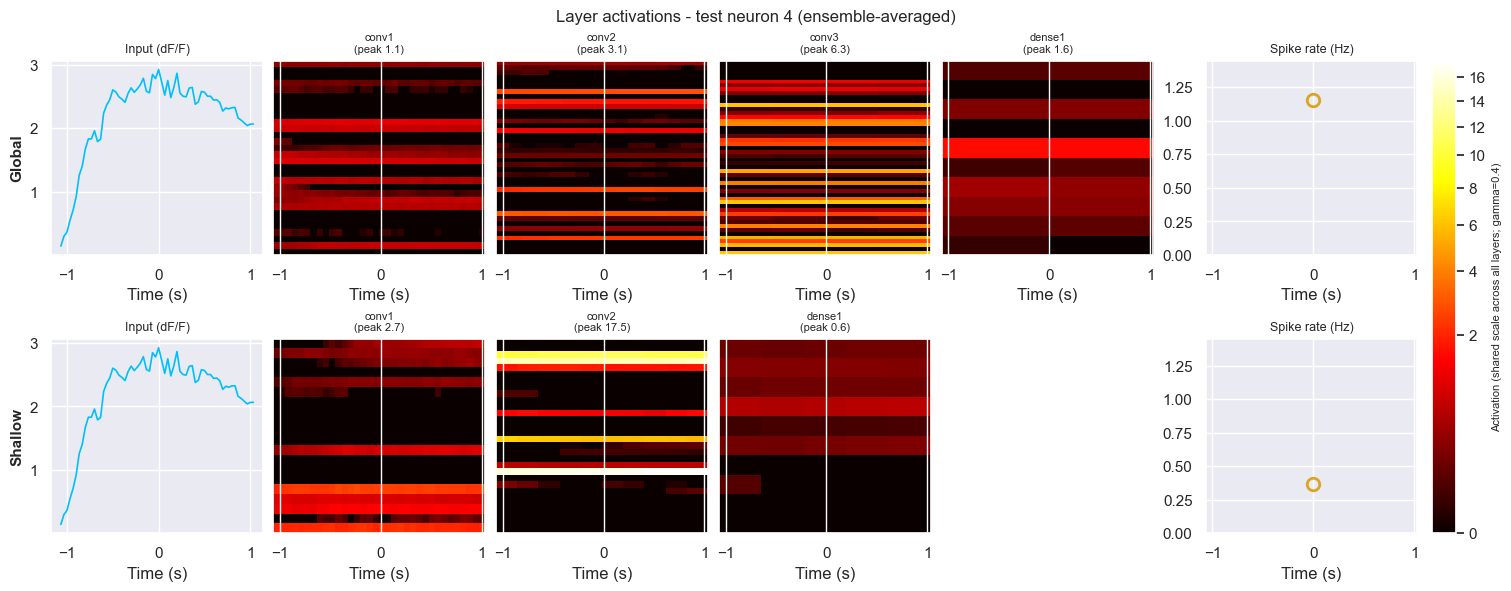

In [15]:
# ============================================================================
# Per-layer activation maps for the Global (3-conv) and Shallow (2-conv) models
# Input dF/F -> layer heatmaps -> spike-rate output, one row per model.
# All heatmaps share ONE colour scale (comparable across layers/models). A
# PowerNorm (gamma<1) lifts the low end so weak layers stay visible instead of
# going black. The two spike-rate panels also share one y-axis.
# ============================================================================
import os, glob, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import OrderedDict
from cascade2p import config as cascade_config

# ---- 1. capture activations of one dF/F window via forward hooks -----------
def collect_activations(model, window, device='cpu'):
    """Run ONE dF/F window through `model`; return {layer_name: (units x time)}
    (post-ReLU) and the scalar spike-rate output. Architecture-agnostic."""
    model.eval().to(device); recs = OrderedDict(); hooks = []
    def make_hook(name):
        def hook(m, inp, out):
            a = out.detach().cpu().numpy()[0]                       # drop batch
            arr = a if isinstance(m, nn.Conv1d) else (a.T if a.ndim == 2 else a[:, None])
            recs[name] = np.maximum(arr, 0)                         # show post-ReLU
        return hook
    for name, m in model.named_modules():
        if isinstance(m, nn.Conv1d) or (isinstance(m, nn.Linear) and m.out_features > 1):
            hooks.append(m.register_forward_hook(make_hook(name)))
    x = torch.as_tensor(np.asarray(window, np.float32).reshape(1, -1, 1)).to(device)
    with torch.no_grad():
        out = model(x)
    for h in hooks:
        h.remove()
    return recs, float(np.ravel(out.cpu().numpy())[0])

# ---- 2. average activations (and the rate) across an ensemble --------------
def ensemble_activations(models, window, device='cpu'):
    summed = None; rate = 0.0
    for mdl in models:
        r, sr = collect_activations(mdl, window, device); rate += sr
        if summed is None:
            summed = OrderedDict((k, v.copy()) for k, v in r.items())
        else:
            for k in summed:
                summed[k] += r[k]
    n = len(models)
    return OrderedDict((k, v / n) for k, v in summed.items()), rate / n

# ---- 3. load all ensemble members of a model (pass the right builder) ------
def load_ensemble(model_path, noise_level, builder, device='cpu'):
    """builder = utils.define_model (Global/3-conv) or helper.shallower_model (Shallow/2-conv)."""
    cfg = cascade_config.read_config(os.path.join(model_path, 'config.yaml'))
    if cfg is None:
        raise ValueError(f"Config at '{model_path}/config.yaml' is empty/corrupt - retrain or regenerate.")
    files = sorted(glob.glob(os.path.join(model_path, f"Model_NoiseLevel_{int(noise_level)}_Ensemble_*.pth")))
    if not files:
        raise FileNotFoundError(f"No .pth for noise level {noise_level} in {model_path}")
    models = []
    for f in files:
        m = builder(cfg['filter_sizes'], cfg['filter_numbers'], cfg['dense_expansion'],
                    cfg['windowsize'], cfg['loss_function'], cfg['optimizer'])
        m.load_state_dict(torch.load(f, map_location=device)); m.eval(); models.append(m)
    return models, cfg['windowsize']

# ---- 4. draw one row: input | layer heatmaps | spike-rate point ------------
def plot_activations(window, records, spike_rate, frame_rate, axes_row, n_cols, norm,
                     row_label='', rate_ymax=None):
    """`norm` is a SHARED matplotlib normalization used for every heatmap, so
    colours are comparable across layers and models. Returns the last imshow
    handle (for the shared colorbar). `rate_ymax` fixes the spike-rate y-axis."""
    t = (np.arange(len(window)) - len(window)//2) / frame_rate
    axes_row[0].plot(t, window, color='deepskyblue', lw=1.2)
    axes_row[0].set_title('Input (dF/F)', fontsize=9); axes_row[0].set_xlabel('Time (s)')
    if row_label:
        axes_row[0].set_ylabel(row_label, fontsize=11, fontweight='bold')
    im = None
    for k, (name, arr) in enumerate(records.items()):
        ax = axes_row[k + 1]
        im = ax.imshow(arr, aspect='auto', cmap='hot', origin='lower', norm=norm,
                       extent=[t[0], t[-1], 0, arr.shape[0]])
        ax.set_title(f'{name}\n(peak {arr.max():.1f})', fontsize=8)
        ax.set_yticks([]); ax.set_xlabel('Time (s)')
    for j in range(1 + len(records), n_cols - 1):                   # blank unused layer slots
        axes_row[j].axis('off')
    axes_row[-1].plot(0, spike_rate * frame_rate, 'o', mfc='none', mec='goldenrod', ms=9, mew=2)
    axes_row[-1].set_title('Spike rate (Hz)', fontsize=9)
    axes_row[-1].set_xlim(t[0], t[-1]); axes_row[-1].set_xlabel('Time (s)')
    axes_row[-1].set_ylim(0, rate_ymax)                            # shared across rows
    return im

# ---- 5. run it: load both ensembles, pick a transient, plot two rows -------
glob_models, ws_g = load_ensemble('Global_30Hz_25ms_baseline',      noise_level=2, builder=utils.define_model)
shal_models, ws_s = load_ensemble('Global_30Hz_25ms_shallow_model', noise_level=2, builder=helper.shallower_model)

def extract_window(trace, center_idx, windowsize):
    half = windowsize // 2
    idx = np.clip(np.arange(center_idx - half, center_idx - half + windowsize), 0, len(trace) - 1)
    return trace[idx]

neuron = 4                                                          # pick any test neuron
center = int(np.nanargmax(traces[neuron]))                          # centre window on its biggest transient
win_g = extract_window(traces[neuron], center, ws_g)
win_s = extract_window(traces[neuron], center, ws_s)

recs_g, sr_g = ensemble_activations(glob_models, win_g)
recs_s, sr_s = ensemble_activations(shal_models, win_s)

n_cols    = 2 + max(len(recs_g), len(recs_s))                       # keep both rows aligned
rate_ymax = 1.25 * max(sr_g, sr_s) * frame_rate                    # common spike-rate y-scale

# ONE shared colour scale for all heatmaps; gamma<1 keeps weak layers visible
vmax = max(arr.max() for recs in (recs_g, recs_s) for arr in recs.values())
norm = mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=vmax)

fig, axs = plt.subplots(2, n_cols, figsize=(2.5 * n_cols, 5.8), layout='constrained')
im = plot_activations(win_g, recs_g, sr_g, frame_rate, axs[0], n_cols, norm, 'Global',  rate_ymax)
plot_activations(win_s, recs_s, sr_s, frame_rate, axs[1], n_cols, norm, 'Shallow', rate_ymax)

cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.01)           # one shared colorbar
cbar.set_label('Activation (shared scale across all layers; gamma=0.4)', fontsize=8)
fig.suptitle(f'Layer activations - test neuron {neuron} (ensemble-averaged)', fontsize=12)
plt.show()

Input: the ~2 s calcium window the network actually sees — here a strong transient that rises into t = 0 and decays after.
Spike rate (Hz): one open circle at t = 0 — each forward pass outputs a single predicted rate for the center bin (that's why it's a point, not a curve). Global = 1.16 Hz, Shallow = 0.37 Hz for this window.
the activations get sparser and sharper with depth: onv2 / conv3 become fewer, brighter bands (activity concentrates, peak magnitude climbs 1→3→6). The network is combining the simple features into a few strongly-selective "an event is happening here" detector
Global vs Shallow (actual comparison)
The Shallow model has one fewer conv layer, so it must do the same job in two convs — and you can see the strain: its conv2 peaks at 17.5 (vs Global's conv2 at 3.1) and is the sparsest layer (0.20 active). One or two filters are firing very hard — conv2 is overloaded, absorbing the work Global spreads across conv2 and conv3.
Shallow's dense1 spans 5 time columns vs Global's 2 (one pooling step instead of two). So its final representation keeps more temporal detail but is less deeply abstracted.
For this window the shallow model is more conservative in its output (0.37 vs 1.16 Hz). That ties back to your correlation boxplot: if Shallow underperforms, this is a mechanistic "why" — fewer stages to refine the event features, so the readout is noisier/weaker.

# to do:
1. test the trained model
2. generate the plots you want
3. think of other parts to train_architecture
4. draft poster write update_display
5. clean notebook and add comments